# Name: Aleena fatima
# RollNo: 22F-3474
# Section: 8A


In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, confusion_matrix

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

Device: cpu


In [4]:
from torchvision.datasets import ImageFolder
import os

class CleanImageFolder(ImageFolder):
    def find_classes(self, directory):
        # Only take valid class folders (ignore hidden folders like .ipynb_checkpoints)
        classes = [
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d)) and not d.startswith('.')
        ]
        classes.sort()
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx


data_dir = r"C:\Users\ADEEL AHMAED\Downloads\archive\PCB_DATASET\images"

dataset = CleanImageFolder(root=data_dir, transform=train_transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
Total Images: 693


In [5]:
import os
print(os.listdir(data_dir))

['.ipynb_checkpoints', 'CV_A3.ipynb', 'Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


In [6]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

val_data.dataset.transform = test_transform
test_data.dataset.transform = test_transform

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 485
Val: 103
Test: 105


In [7]:
from collections import Counter

labels = [label for _, label in dataset]
print(Counter(labels))

Counter({2: 116, 3: 116, 5: 116, 0: 115, 1: 115, 4: 115})


In [8]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model_cnn = CustomCNN(len(dataset.classes)).to(device)

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.skip = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.skip(x)
        return torch.relu(out)


class ResNetCustom(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.layer1 = ResidualBlock(3, 64)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

model_resnet = ResNetCustom(len(dataset.classes)).to(device)

In [10]:
def train_model(model, train_loader, val_loader, epochs=30):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.3f}, Val={val_loss:.3f}")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")

    return train_losses, val_losses

In [11]:
cnn_train, cnn_val = train_model(model_cnn, train_loader, val_loader)

Epoch 1: Train=184.228, Val=9.213
Epoch 2: Train=51.010, Val=8.904
Epoch 3: Train=29.753, Val=7.173
Epoch 4: Train=28.724, Val=7.162
Epoch 5: Train=28.703, Val=7.162
Epoch 6: Train=28.683, Val=7.163
Epoch 7: Train=28.669, Val=7.163
Epoch 8: Train=28.673, Val=7.164
Epoch 9: Train=28.675, Val=7.166
Epoch 10: Train=28.670, Val=7.167
Epoch 11: Train=28.678, Val=7.168
Epoch 12: Train=28.664, Val=7.171
Epoch 13: Train=28.662, Val=7.171
Epoch 14: Train=28.666, Val=7.173
Epoch 15: Train=28.671, Val=7.173
Epoch 16: Train=28.653, Val=7.174
Epoch 17: Train=28.658, Val=7.175
Epoch 18: Train=28.665, Val=7.176
Epoch 19: Train=28.659, Val=7.177
Epoch 20: Train=28.659, Val=7.178
Epoch 21: Train=28.640, Val=7.178
Epoch 22: Train=28.655, Val=7.180
Epoch 23: Train=28.652, Val=7.180
Epoch 24: Train=28.656, Val=7.181
Epoch 25: Train=28.663, Val=7.182
Epoch 26: Train=28.678, Val=7.181
Epoch 27: Train=28.658, Val=7.181
Epoch 28: Train=28.640, Val=7.182
Epoch 29: Train=28.650, Val=7.183
Epoch 30: Train=28.654

In [12]:
res_train, res_val = train_model(model_resnet, train_loader, val_loader, epochs=10)

Epoch 1: Train=29.847, Val=7.932
Epoch 2: Train=29.083, Val=7.271
Epoch 3: Train=28.902, Val=7.206
Epoch 4: Train=28.726, Val=7.278
Epoch 5: Train=28.763, Val=7.292
Epoch 6: Train=28.796, Val=7.250
Epoch 7: Train=28.779, Val=7.238
Epoch 8: Train=28.784, Val=7.284
Epoch 9: Train=28.811, Val=7.311
Epoch 10: Train=28.669, Val=7.283


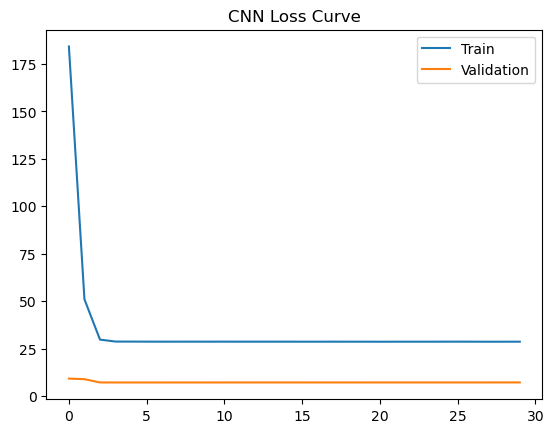

In [13]:
plt.plot(cnn_train, label="Train")
plt.plot(cnn_val, label="Validation")
plt.legend()
plt.title("CNN Loss Curve")
plt.show()

In [14]:
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            preds.extend(torch.argmax(out, 1).cpu().numpy())
            labels.extend(y.numpy())

    print(classification_report(labels, preds))

    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True)
    plt.show()

C:\Users\ADEEL AHMAED\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADEEL AHMAED\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADEEL AHMAED\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.00      0.00      0.00        12
           2       0.00      0.00      0.00        17
           3       0.00      0.00      0.00        22
           4       0.00      0.00      0.00        21
           5       0.15      1.00      0.26        16

    accuracy                           0.15       105
   macro avg       0.03      0.17      0.04       105
weighted avg       0.02      0.15      0.04       105



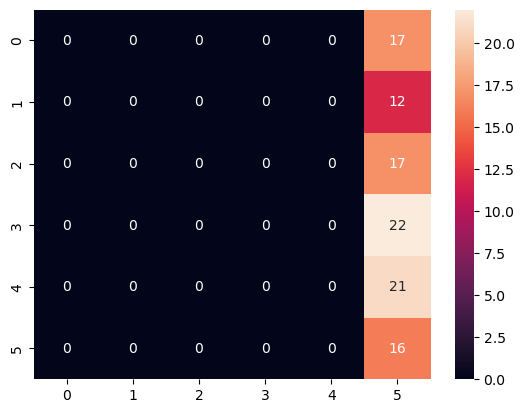

C:\Users\ADEEL AHMAED\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADEEL AHMAED\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADEEL AHMAED\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.08      0.42      0.14        12
           2       0.00      0.00      0.00        17
           3       0.00      0.00      0.00        22
           4       0.06      0.05      0.05        21
           5       0.11      0.12      0.12        16

    accuracy                           0.08       105
   macro avg       0.04      0.10      0.05       105
weighted avg       0.04      0.08      0.04       105



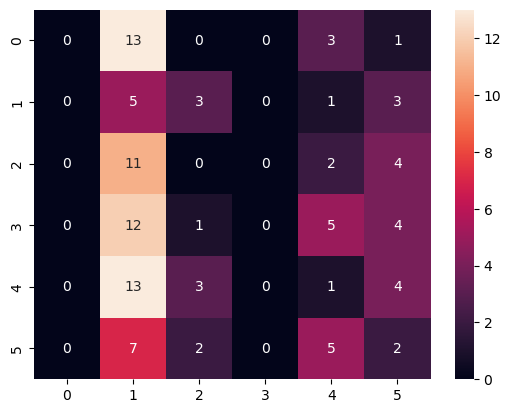

In [15]:
evaluate(model_cnn, test_loader)
evaluate(model_resnet, test_loader)

In [16]:
def show_predictions(model, loader):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device)

    out = model(x)
    preds = torch.argmax(out, 1)

    for i in range(6):
        plt.figure()
        img = x[i].cpu().squeeze()   # 🔥 grayscale
        plt.imshow(img, cmap='gray') # 🔥 force grayscale
        plt.title(f"Pred: {preds[i]} | True: {y[i]}")
        plt.axis('off')
        plt.show()

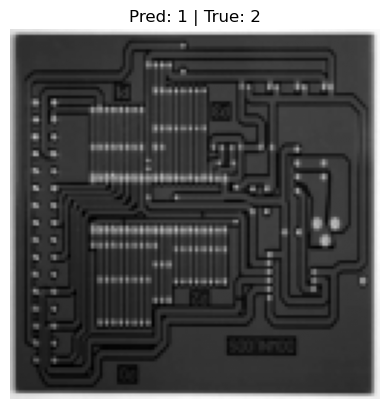

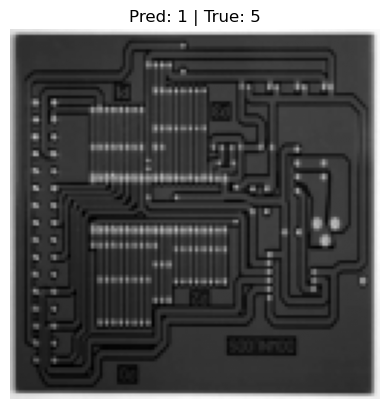

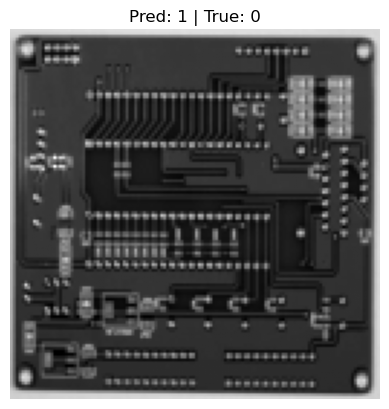

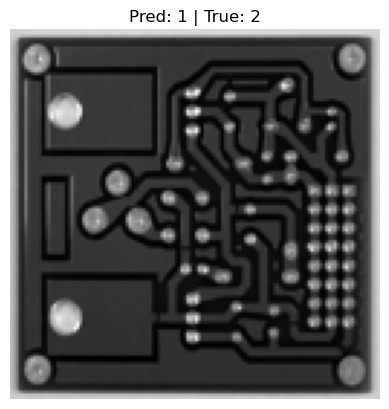

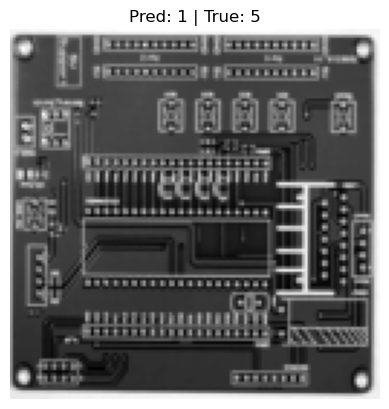

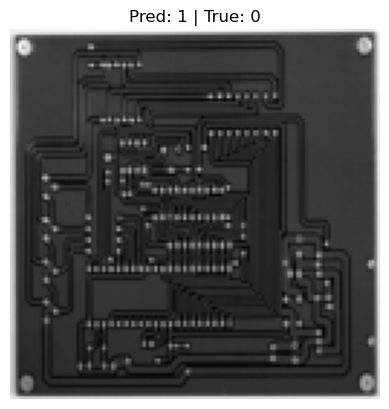

In [17]:
show_predictions(model, test_loader)